In [3]:
pip install pandas faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

# Initialize Faker
fake = Faker()

# Number of Patients
NUM_PATIENTS = 1000

# Departments and Doctors
departments = {
    "Emergency": ["Dr. Sharma", "Dr. Kumar"],
    "Cardiology": ["Dr. Mehta", "Dr. Patel"],
    "Orthopedics": ["Dr. Reddy", "Dr. Singh"],
    "Neurology": ["Dr. Rao", "Dr. Gupta"],
    "Pediatrics": ["Dr. Verma", "Dr. Iyer"],
    "General Medicine": ["Dr. Thomas", "Dr. Joseph"]
}

# Diagnoses by Department
diagnosis = {
    "Emergency": ["Accident", "High Fever", "Chest Pain"],
    "Cardiology": ["Hypertension", "Heart Disease", "Chest Pain"],
    "Orthopedics": ["Fracture", "Back Pain", "Joint Pain"],
    "Neurology": ["Migraine", "Epilepsy", "Stroke"],
    "Pediatrics": ["Viral Fever", "Cold", "Asthma"],
    "General Medicine": ["Diabetes", "Food Poisoning", "Viral Infection"]
}

# Activities without Lab Test
activities_without_lab = [
    "Registration",
    "Triage",
    "Doctor",
    "Billing"
]

# Activities with Lab Test
activities_with_lab = [
    "Registration",
    "Triage",
    "Doctor",
    "Lab Test",
    "Doctor",
    "Billing"
]

# Waiting Time Ranges (minutes)
waiting_range = {
    "Registration": (0, 10),
    "Triage": (5, 15),
    "Doctor": (10, 45),
    "Lab Test": (5, 20),
    "Billing": (2, 10)
}

# Treatment Time Ranges (minutes)
treatment_range = {
    "Registration": (3, 8),
    "Triage": (5, 10),
    "Doctor": (10, 20),
    "Lab Test": (10, 20),
    "Billing": (3, 6)
}

rows = []

# Generate Dataset
for patient in range(1, NUM_PATIENTS + 1):

    patient_id = f"P{patient:04d}"
    case_id = f"C{patient:04d}"

    name = fake.name()
    age = random.randint(1, 90)
    gender = random.choice(["Male", "Female"])

    visit_date = fake.date_between(start_date="-30d", end_date="today")

    department = random.choice(list(departments.keys()))
    doctor = random.choice(departments[department])
    disease = random.choice(diagnosis[department])

    priority = random.choices(
        ["Normal", "Emergency"],
        weights=[80, 20]
    )[0]

    status = "Completed"

    billing = random.choices(
        ["Paid", "Pending"],
        weights=[90, 10]
    )[0]

    has_lab = random.choices(
        [True, False],
        weights=[30, 70]
    )[0]

    if has_lab:
        activities = activities_with_lab
        lab = "Yes"
    else:
        activities = activities_without_lab
        lab = "No"

    current_time = datetime.combine(
        visit_date,
        datetime.strptime("08:00", "%H:%M").time()
    ) + timedelta(minutes=random.randint(0, 600))

    for activity in activities:

        waiting = random.randint(
            waiting_range[activity][0],
            waiting_range[activity][1]
        )

        start = current_time + timedelta(minutes=waiting)

        treatment = random.randint(
            treatment_range[activity][0],
            treatment_range[activity][1]
        )

        end = start + timedelta(minutes=treatment)

        rows.append({
            "Patient_ID": patient_id,
            "Patient_Name": name,
            "Age": age,
            "Gender": gender,
            "Visit_Date": visit_date,
            "Department": department,
            "Doctor_Name": doctor,
            "Activity": activity,
            "Activity_Start_Time": start.strftime("%H:%M"),
            "Activity_End_Time": end.strftime("%H:%M"),
            "Waiting_Time_Minutes": waiting,
            "Treatment_Time": treatment,
            "Case_ID": case_id,
            "Status": status,
            "Priority": priority,
            "Diagnosis": disease,
            "Lab_Test": lab,
            "Billing_Status": billing
        })

        current_time = end

# Create DataFrame
df = pd.DataFrame(rows)

# Save CSV
df.to_csv("Patient_Event_Log.csv", index=False)

print("Dataset generated successfully!")
print("Rows:", len(df))
print("File saved as Patient_Event_Log.csv")

Dataset generated successfully!
Rows: 4584
File saved as Patient_Event_Log.csv


In [5]:
from google.colab import files

# Save the dataset
df.to_csv("Patient_Event_Log.csv", index=False)

# Download the CSV file
files.download("Patient_Event_Log.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
print(df.isnull().sum())

Patient_ID              0
Patient_Name            0
Age                     0
Gender                  0
Visit_Date              0
Department              0
Doctor_Name             0
Activity                0
Activity_Start_Time     0
Activity_End_Time       0
Waiting_Time_Minutes    0
Treatment_Time          0
Case_ID                 0
Status                  0
Priority                0
Diagnosis               0
Lab_Test                0
Billing_Status          0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
!pip install matplotlib seaborn

In [9]:
print("===================================")
print("DATASET INFORMATION")
print("===================================")

print(df.info())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4584 entries, 0 to 4583
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Patient_ID            4584 non-null   object
 1   Patient_Name          4584 non-null   object
 2   Age                   4584 non-null   int64 
 3   Gender                4584 non-null   object
 4   Visit_Date            4584 non-null   object
 5   Department            4584 non-null   object
 6   Doctor_Name           4584 non-null   object
 7   Activity              4584 non-null   object
 8   Activity_Start_Time   4584 non-null   object
 9   Activity_End_Time     4584 non-null   object
 10  Waiting_Time_Minutes  4584 non-null   int64 
 11  Treatment_Time        4584 non-null   int64 
 12  Case_ID               4584 non-null   object
 13  Status                4584 non-null   object
 14  Priority              4584 non-null   object
 15  Diagnosis         

In [10]:
print(df.describe())

print("\nCategorical Summary")

print(df.describe(include='object'))

               Age  Waiting_Time_Minutes  Treatment_Time
count  4584.000000           4584.000000     4584.000000
mean     45.235166             13.130890        9.032723
std      26.259969             11.043183        5.005062
min       1.000000              0.000000        3.000000
25%      22.000000              6.000000        5.000000
50%      45.000000              9.000000        7.000000
75%      68.000000             16.000000       13.000000
max      90.000000             45.000000       20.000000

Categorical Summary
       Patient_ID       Patient_Name Gender  Visit_Date Department  \
count        4584               4584   4584        4584       4584   
unique       1000                994      2          30          6   
top         P0011  Christopher Smith   Male  2026-07-23  Neurology   
freq            6                 10   2296         220        846   

       Doctor_Name Activity Activity_Start_Time Activity_End_Time Case_ID  \
count         4584     4584           

In [11]:
total_patients = df["Patient_ID"].nunique()

print("Total Patients:", total_patients)

Total Patients: 1000


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in Colab
%matplotlib inline

# Better plot style
plt.style.use('ggplot')

Gender
Male      2296
Female    2288
Name: count, dtype: int64


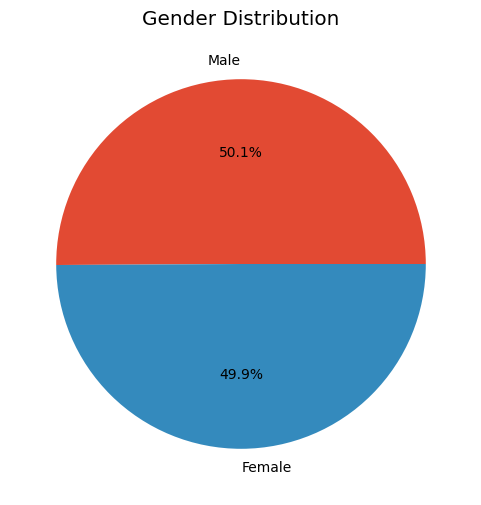

In [15]:
print(df["Gender"].value_counts())

plt.figure(figsize=(6,6))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

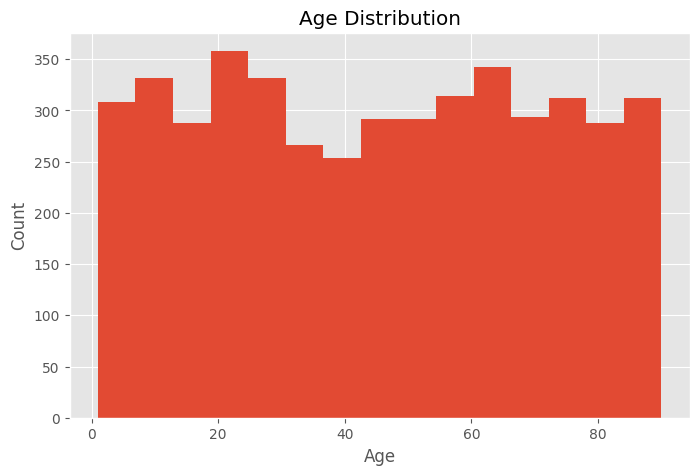

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

Department
Neurology           846
Pediatrics          824
General Medicine    788
Cardiology          752
Orthopedics         740
Emergency           634
Name: count, dtype: int64


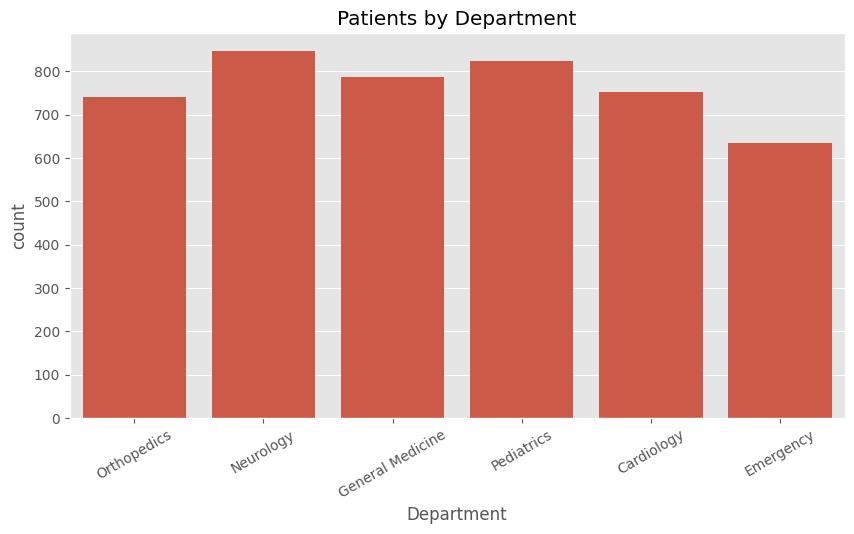

In [17]:
print(df["Department"].value_counts())

plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Department")

plt.xticks(rotation=30)

plt.title("Patients by Department")

plt.show()

Doctor_Name
Dr. Iyer      430
Dr. Gupta     430
Dr. Mehta     426
Dr. Rao       416
Dr. Joseph    416
Dr. Verma     394
Dr. Reddy     372
Dr. Thomas    372
Dr. Singh     368
Dr. Kumar     340
Dr. Patel     326
Dr. Sharma    294
Name: count, dtype: int64


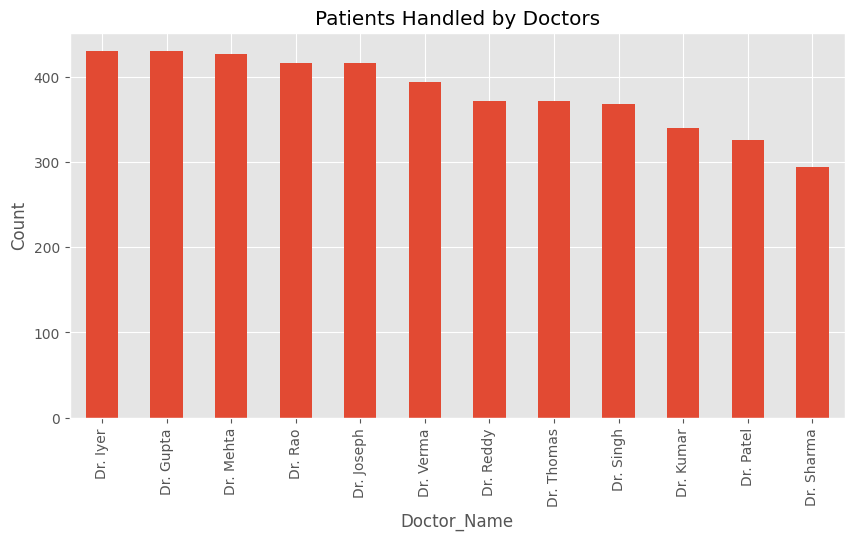

In [18]:
doctor_counts = df["Doctor_Name"].value_counts()

print(doctor_counts)

plt.figure(figsize=(10,5))

doctor_counts.plot(kind="bar")

plt.title("Patients Handled by Doctors")

plt.ylabel("Count")

plt.show()

Diagnosis
Chest Pain         524
Stroke             318
Asthma             304
Epilepsy           290
Cold               284
Back Pain          278
Food Poisoning     268
Diabetes           260
Heart Disease      260
Viral Infection    260
Migraine           238
Viral Fever        236
Fracture           232
Joint Pain         230
High Fever         204
Hypertension       200
Accident           198
Name: count, dtype: int64


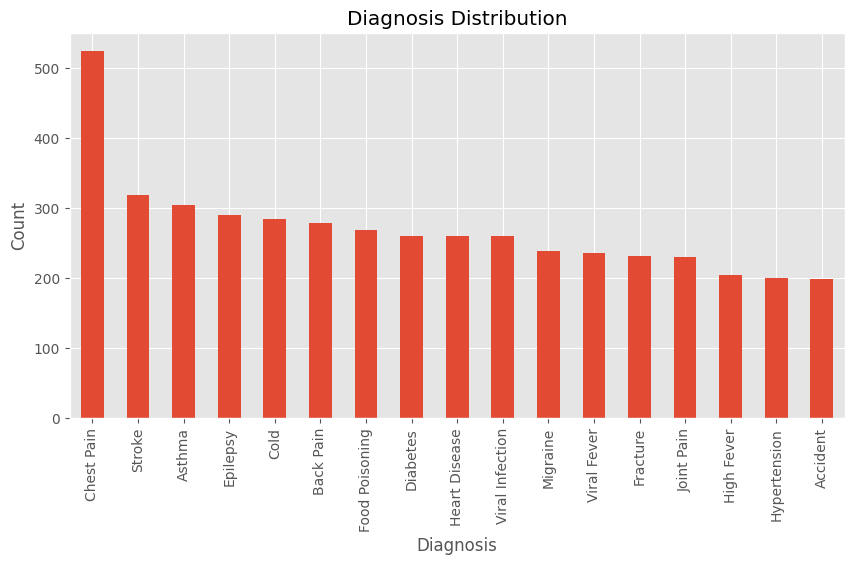

In [19]:
diagnosis = df["Diagnosis"].value_counts()

print(diagnosis)

plt.figure(figsize=(10,5))

diagnosis.plot(kind="bar")

plt.title("Diagnosis Distribution")

plt.ylabel("Count")

plt.show()

Priority
Normal       3670
Emergency     914
Name: count, dtype: int64


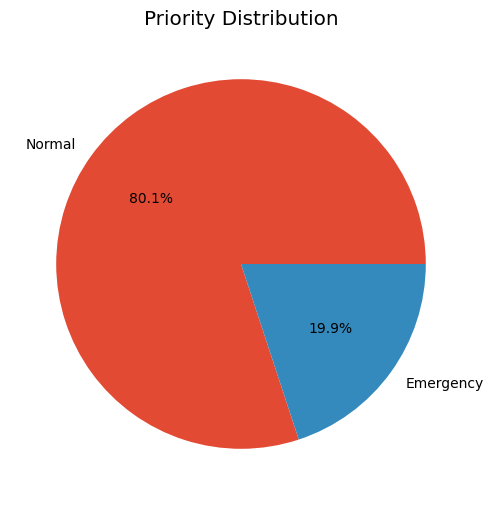

In [20]:
priority = df["Priority"].value_counts()

print(priority)

priority.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Priority Distribution")

plt.ylabel("")

plt.show()

Billing_Status
Paid       4058
Pending     526
Name: count, dtype: int64


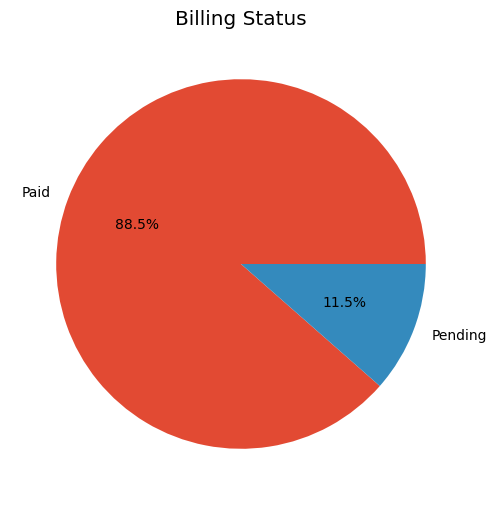

In [21]:
billing = df["Billing_Status"].value_counts()

print(billing)

billing.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Billing Status")

plt.ylabel("")

plt.show()

Lab_Test
No     2832
Yes    1752
Name: count, dtype: int64


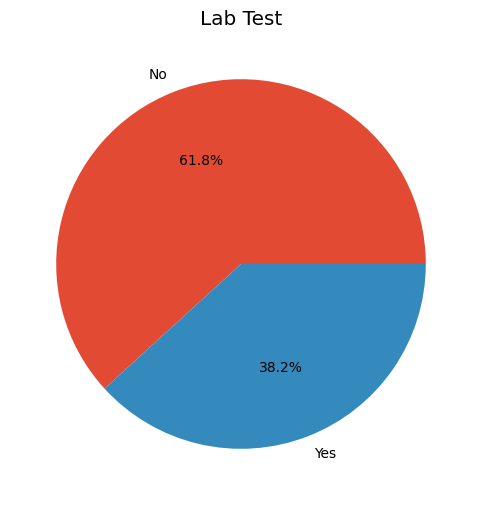

In [22]:
lab = df["Lab_Test"].value_counts()

print(lab)

lab.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Lab Test")

plt.ylabel("")

plt.show()

count    4584.000000
mean       13.130890
std        11.043183
min         0.000000
25%         6.000000
50%         9.000000
75%        16.000000
max        45.000000
Name: Waiting_Time_Minutes, dtype: float64


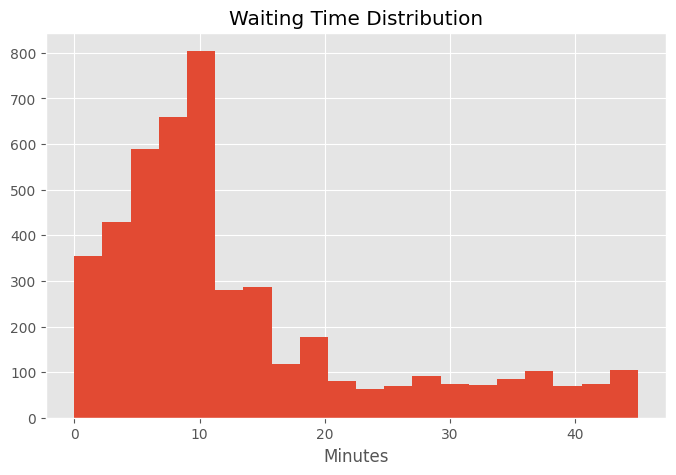

In [23]:
print(df["Waiting_Time_Minutes"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["Waiting_Time_Minutes"], bins=20)

plt.title("Waiting Time Distribution")

plt.xlabel("Minutes")

plt.show()

count    4584.000000
mean        9.032723
std         5.005062
min         3.000000
25%         5.000000
50%         7.000000
75%        13.000000
max        20.000000
Name: Treatment_Time, dtype: float64


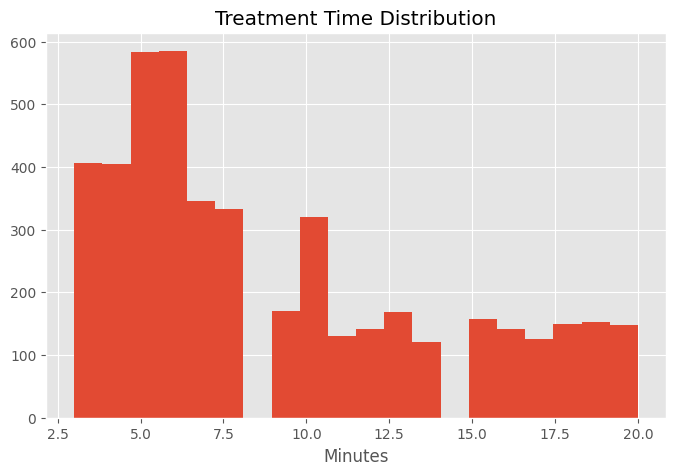

In [24]:
print(df["Treatment_Time"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["Treatment_Time"], bins=20)

plt.title("Treatment Time Distribution")

plt.xlabel("Minutes")

plt.show()

Department
Cardiology          13.500000
Emergency           13.042587
General Medicine    13.107868
Neurology           13.143026
Orthopedics         13.162162
Pediatrics          12.843447
Name: Waiting_Time_Minutes, dtype: float64


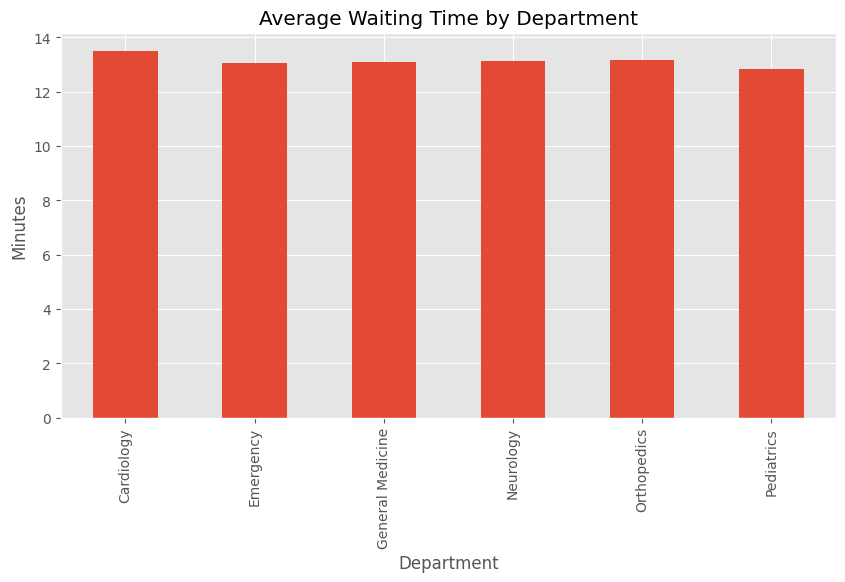

In [25]:
department_wait = df.groupby("Department")["Waiting_Time_Minutes"].mean()

print(department_wait)

department_wait.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Waiting Time by Department")

plt.ylabel("Minutes")

plt.show()

Department
Cardiology          9.074468
Emergency           8.998423
General Medicine    9.143401
Neurology           8.839243
Orthopedics         9.037838
Pediatrics          9.109223
Name: Treatment_Time, dtype: float64


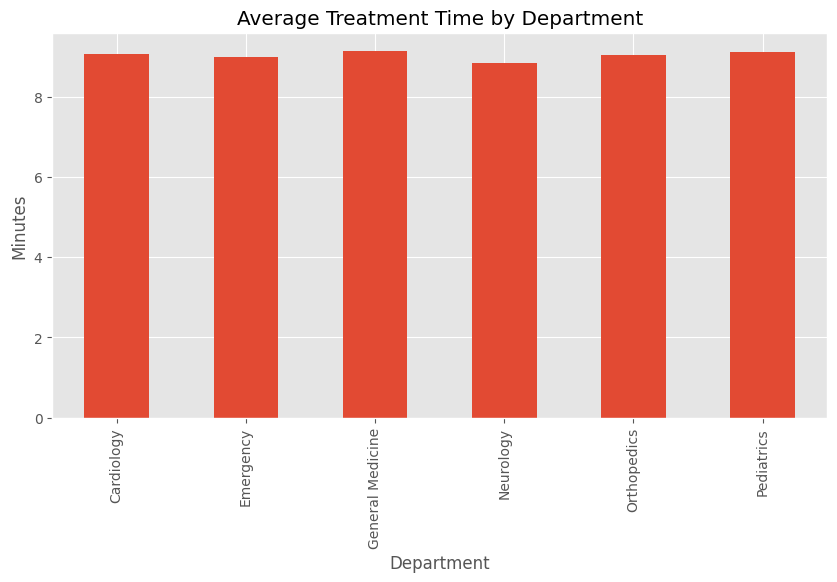

In [26]:
department_treat = df.groupby("Department")["Treatment_Time"].mean()

print(department_treat)

department_treat.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Treatment Time by Department")

plt.ylabel("Minutes")

plt.show()

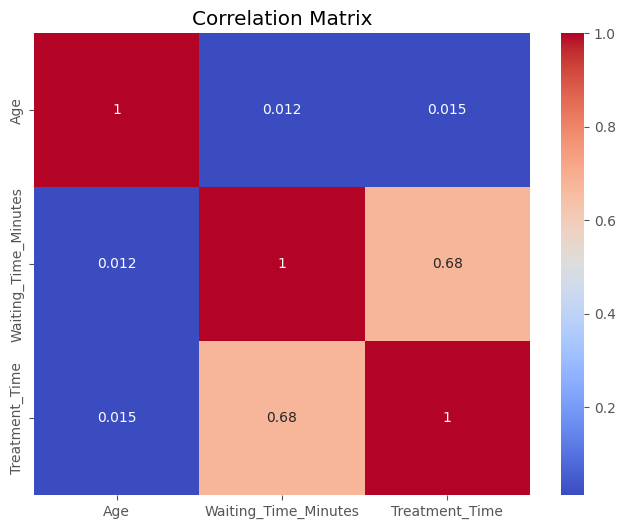

In [27]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [28]:
print("\n========== KPI REPORT ==========")

print("Total Patients:", df["Patient_ID"].nunique())

print("Total Departments:", df["Department"].nunique())

print("Total Doctors:", df["Doctor_Name"].nunique())

print("Average Age:", round(df["Age"].mean(),2))

print("Average Waiting Time:",
      round(df["Waiting_Time_Minutes"].mean(),2))

print("Average Treatment Time:",
      round(df["Treatment_Time"].mean(),2))

print("Emergency Cases:",
      (df["Priority"]=="Emergency").sum())

print("Normal Cases:",
      (df["Priority"]=="Normal").sum())

print("Lab Tests:",
      (df["Lab_Test"]=="Yes").sum())

print("Paid Bills:",
      (df["Billing_Status"]=="Paid").sum())

print("Pending Bills:",
      (df["Billing_Status"]=="Pending").sum())


========== KPI REPORT ==========
Total Patients: 1000
Total Departments: 6
Total Doctors: 12
Average Age: 45.24
Average Waiting Time: 13.13
Average Treatment Time: 9.03
Emergency Cases: 914
Normal Cases: 3670
Lab Tests: 1752
Paid Bills: 4058
Pending Bills: 526
